In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load dataset
df = pd.read_csv("StudentsPerformance_modified.csv")

In [6]:
# Preview data
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group C,high school,standard,none,70,82,66
1,female,group B,associate's degree,free/reduced,none,50,67,72
2,female,group E,some college,standard,none,71,79,75
3,female,group B,associate's degree,standard,none,80,91,84
4,female,group C,some college,free/reduced,none,74,89,92


In [7]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
# Statistical summary
df.describe()

,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,65.928000,69.089000,67.929000
std,15.331597,14.862974,15.242713
min,2.000000,15.000000,9.000000
25%,56.000000,59.000000,57.000000
50%,66.000000,70.000000,69.000000
75%,76.000000,80.000000,79.000000
max,100.000000,100.000000,100.000000


In [9]:
# Overall averages
overall_math = df['math score'].mean()
overall_reading = df['reading score'].mean()
overall_writing = df['writing score'].mean()
overall_combined = (overall_math + overall_reading + overall_writing ) / 3

print("Overall Performance:")
print("------------------------------")
print(" Math Score:", overall_math)
print(" Reading Score:", overall_reading)
print(" Writing Score:", overall_writing)
print(" Combined Average:", round(overall_combined,2))


Overall Performance:
------------------------------
 Math Score: 65.928
 Reading Score: 69.089
 Writing Score: 67.929
 Combined Average: 67.65


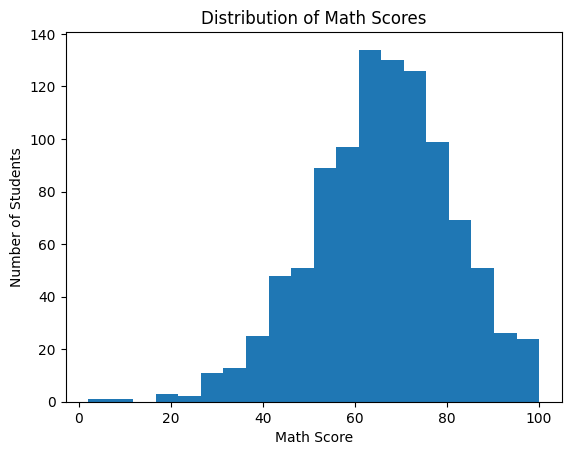

In [10]:
# Histogram of Math Scores
plt.hist(df["math score"], bins=20)
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.show()

AVERAGE SCORES BY GENDER
------------------------
        math score  reading score  writing score
gender                                          
female   63.594595      72.480695      72.046332
male     68.435685      65.443983      63.504149


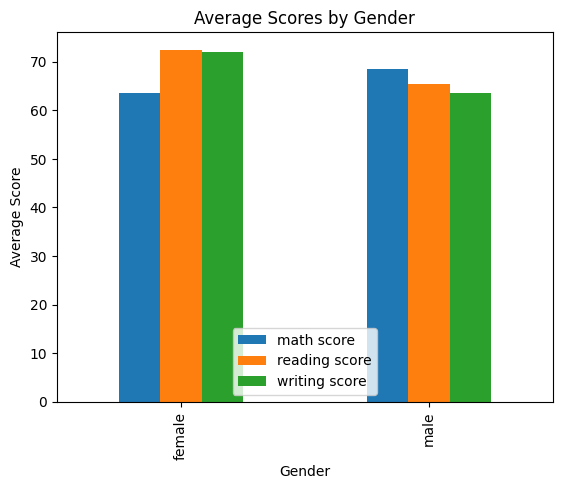

In [12]:
# Average scores by gender
gender_avg = df.groupby("gender")[["math score", "reading score", "writing score"]].mean()

print("AVERAGE SCORES BY GENDER")
print("------------------------")
print(gender_avg)

gender_avg.plot(kind="bar")
plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.show()

AVERAGE SCORES BY TEST PREPARATION
-----------------------------------
                         math score  reading score  writing score
test preparation course                                          
completed                 69.382682      73.793296      74.212291
none                      64.001558      66.465732      64.425234


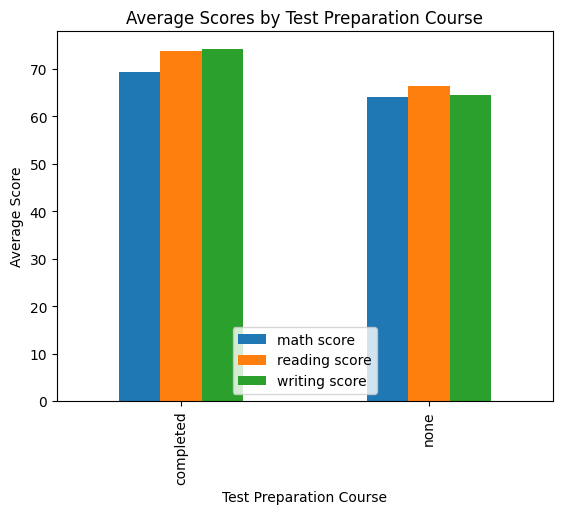

In [13]:
# Average scores by test preparation
testprep_avg = df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean()

print("AVERAGE SCORES BY TEST PREPARATION")
print("-----------------------------------")
print(testprep_avg)

testprep_avg.plot(kind="bar")
plt.title("Average Scores by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.show()

In [14]:
# Score improvement due to test prep
difference = testprep_avg.loc["completed"] - testprep_avg.loc["none"]

print("Score Improvement (Completed - None)")
print(difference)

Score Improvement (Completed - None)
math score       5.381124
reading score    7.327564
writing score    9.787057
dtype: float64


AVERAGE SCORES BY LUNCH TYPE
--------------------------------
              math score  reading score  writing score
lunch                                                 
free/reduced   58.935211      64.450704      62.752113
standard       69.776744      71.641860      70.778295


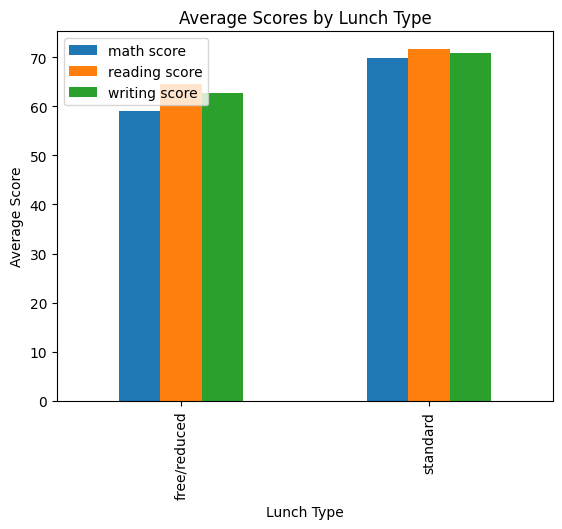

In [15]:
# Average scores by lunch type
lunch_avg = df.groupby("lunch")[["math score", "reading score", "writing score"]].mean()

print("AVERAGE SCORES BY LUNCH TYPE")
print("--------------------------------")
print(lunch_avg)

lunch_avg.plot(kind="bar")
plt.title("Average Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.show()


In [16]:
# Lunch score gap
lunch_difference = lunch_avg.loc["standard"] - lunch_avg.loc["free/reduced"]

print("Score Gap (Standard - Free/Reduced)")
print(lunch_difference)

Score Gap (Standard - Free/Reduced)
math score       10.841533
reading score     7.191156
writing score     8.026182
dtype: float64


In [17]:
# Create average score column
df["average score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

df["average score"].describe()

,average score
count,1000.000000
mean,67.648667
std,14.248151
min,8.666667
25%,58.000000
50%,68.333333
75%,77.666667
max,99.666667


In [18]:
# High performer analysis (top 25%)
threshold = df["average score"].quantile(0.75)
df["high_performer"] = df["average score"] >= threshold

df["high_performer"].value_counts()

,count
high_performer,
False,747
True,253


In [19]:
# Gender distribution among high performers
high_gender = df[df["high_performer"] == True]["gender"].value_counts(normalize=True)

print("Gender Distribution Among High Performers")
print(high_gender)

Gender Distribution Among High Performers
gender
female    0.58498
male      0.41502
Name: proportion, dtype: float64


In [20]:
# Test prep among high performers
high_testprep = df[df["high_performer"] == True]["test preparation course"].value_counts(normalize=True)

print("\nTest Preparation Distribution Among High Performers")
print(high_testprep)


Test Preparation Distribution Among High Performers
test preparation course
none         0.501976
completed    0.498024
Name: proportion, dtype: float64


In [21]:
# Lunch among high performers
high_lunch = df[df["high_performer"] == True]["lunch"].value_counts(normalize=True)

print("\nLunch Distribution Among High Performers")
print(high_lunch)


Lunch Distribution Among High Performers
lunch
standard        0.790514
free/reduced    0.209486
Name: proportion, dtype: float64


In [23]:
# Compare high performers vs others
performance_comparison = df.groupby("high_performer")[["math score", "reading score", "writing score"]].mean()

print("\nAverage Scores: High Performers vs Others")
print(performance_comparison)


Average Scores: High Performers vs Others
                math score  reading score  writing score
high_performer                                          
False            60.032129      63.242303      61.954485
True             83.335968      86.351779      85.569170
